# Preprocessing of the HCP Schaefer 100 Files
(100 connectomes)

In [18]:
from __future__ import annotations

import numpy as np 
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import h5py

from scipy.spatial.distance import cdist

import argparse
import sys
import json
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Tuple, Optional


import bct
from netneurotools.networks import threshold_network, struct_consensus, binarize_network
import networkx as nx

from scipy.spatial.distance import pdist, squareform


from preprocessing.get_distance_matrix import get_distance_matrix_from_coords, get_distance_matrix_from_fiber_lengths
from analysis.structural_measures import analyze_connectomes

from src.preprocessing.preprocessing_setup import setup
from preprocessing.threshold_to_density import threshold_to_density


from src.preprocessing.utils import setup_paths, save_numpy, save_dataframe # TODO: Remove this again, not needed. 


In [19]:
raw_base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/raw/hcp_schaefer_100")
preprocessed_base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset")
preprocessed_base_path.mkdir(parents=True, exist_ok=True)


data = h5py.File(
   raw_base_path / "DTI_fibers_VolNorm_HCP.mat",
)

debugger = None # 10 # or None # THIS IS IMPORTANT AS 100x100x100 is risky in terms of swapping dimensions... 

N_regions = 100
N_subjects = 100
connectomes = np.zeros((N_regions,N_regions,N_subjects))
for subject in range(N_subjects):
    ref = data["DTI_fibers_VolNorm_HCP"][0][subject]
    connectomes[...,subject]=data[ref][()]

connectomes = connectomes.T # Transpose to have shape (subjects, regions, regions) == (n_subj, 100, 100)
coordinates = np.loadtxt(raw_base_path / f"Schaefer_100_MNI_coords.txt") # (100, 5)
coordinates = coordinates[:, :3]  # Keep only 3D columns

In [20]:
# Get distance matrix 
distance_matrix = cdist(coordinates, coordinates)
np.fill_diagonal(distance_matrix, 0) # np.inf)

distance_matrix_path = preprocessed_base_path / "02_distance_matrices"
distance_matrix_path.mkdir(parents=True, exist_ok=True)

np.save(distance_matrix_path / "distance_matrix_100.npy", distance_matrix)

In [21]:
goal_density = 10 
resolution = 100 

connectomes_binarized = []

# Process each animal
for connection_matrix in connectomes:
    # Create binarized versions at different densities
    print(f"  Creating binarized versions:")

    thres_conn, final_density = threshold_to_density(
        conn_wei=connection_matrix, 
        density=goal_density, 
        output_folder=None, 
        conn_type="connectomes"
    )
    connectomes_binarized.append(thres_conn)

if debugger is not None:
    connectomes_binarized = connectomes_binarized[:debugger]
    
connectomes_binarized = np.array(connectomes_binarized)

# Analyze weighted connectome
results = analyze_connectomes(
    connectomes_binarized, 
    distance_matrix,
    comm_mode="estrada_scaled"
)

connectomes_save_path = preprocessed_base_path / "01_connectomes"
connectomes_save_path.mkdir(parents=True, exist_ok=True)
np.save(connectomes_save_path / f"00_connectomes_density{goal_density}.npy", connectomes_binarized)

bin_results = []
for idx, (bin_conn) in enumerate(connectomes_binarized):
    results = analyze_connectomes(
        np.array([bin_conn]),  # Shape: (1, 100, 100)
        distance_matrix,
        comm_mode="estrada_scaled"
    )
    for result in results:
        bin_results.append(result)

# Save binary analysis results
bin_results_df = pd.DataFrame(bin_results)

path_03_graph_measures = preprocessed_base_path / "03_graph_measures"
path_03_graph_measures.mkdir(parents=True, exist_ok=True)

bin_results_df.to_csv(
    path_03_graph_measures / f"df_graph_measures_bin_{resolution}_density_{goal_density}_percent.csv",
    index=False
)
print(f"Binary analysis results saved: {bin_results_df.shape}")
print(path_03_graph_measures / f"df_graph_measures_bin_{resolution}_density_{goal_density}_percent.csv")

  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized versions:

Thresholding at multiple densities:
  Density 10%... Final density: 0.100000 (edges: 495)
  Creating binarized ver

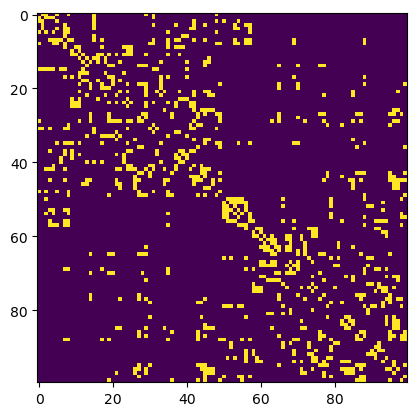

In [22]:
plt.imshow(connectomes_binarized[8], cmap='viridis')

In [23]:
hemiid = [0]*50 + [1]*50  # assuming 100 regions, first 50 left, next 50 right
hemiid = np.array(hemiid).reshape(-1,1)

990
/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/01_connectomes/01_consensus_bin_density_10_percent_100.npy


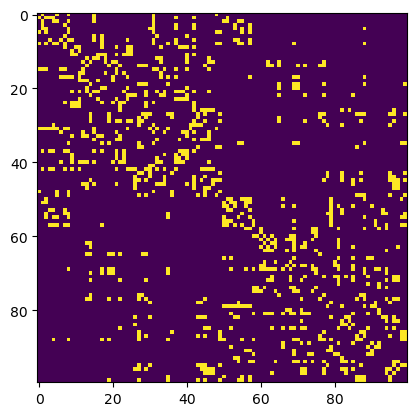

In [24]:
# Get consensus: 


consensus_non_thres = struct_consensus(connectomes.T, distance_matrix, hemiid=hemiid, weighted=True) 
consensus = binarize_network(consensus_non_thres, retain=10).reshape(-1,100,100)
plt.imshow(consensus[0]) # , cmap='gray', interpolation='nearest')

print(sum(consensus[0].flatten()))
np.save(connectomes_save_path / f"01_consensus_bin_density_10_percent_100.npy", consensus)
print(connectomes_save_path / f"01_consensus_bin_density_10_percent_100.npy")


In [25]:
connectomes_binarized.shape

(100, 100, 100)

In [26]:
np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/hcp_schaefer_100_dataset/00_default_animal_0/generated_networks/net_eta-8.0_gamma-0.100000001490117_ruleMatchingIndex_id000.npy").sum()

990.0

In [27]:
import numpy as np

In [28]:
np.load("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed/hcp_schaefer_100_dataset/05_seeds_of_humans_consensus/01_consensus_aimed_for_10_percent_density_bin.npy") 

array([[0, 1, 0, ..., 0, 0, 0],
       [1, 0, 1, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])